# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
2. **Dataset yang digunakan**
   Dataset ini berisi ulasan produk marketplace Indonesia.
   Data terdiri dari teks review dan label sentimen.
   Digunakan untuk analisis sentimen (NLP classification).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [7]:
# Load dataset (file: reviews.csv)
df = pd.read_csv('reviews.csv')

print("Dataset berhasil dimuat")
print("Shape:", df.shape)

display(df.head())

Dataset berhasil dimuat
Shape: (831, 2)


,reviews,label
0,kemeja nya bagusss bgtttt😍😍😍aaaa mauuu nngisss...,1.0
1,"Jahitannya sih rapi,cuman ada benang yang ikut...",0.0
2,Sesuai harga. Agak tipis tapi masih oke kok. W...,0.0
3,"Wah gila sihhh sebagus itu, se worth it, se l...",1.0
4,Kain nya bagus halus \nTapi kok di bukak koto...,0.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   reviews      831 non-null    object 
 1   label        831 non-null    float64
 2   text_length  831 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 19.6+ KB

Missing Values:
reviews        0
label          0
text_length    0
dtype: int64

Kolom dataset:
Index(['reviews', 'label', 'text_length'], dtype='object')

Detected Columns:
Text : reviews
Label: text_length


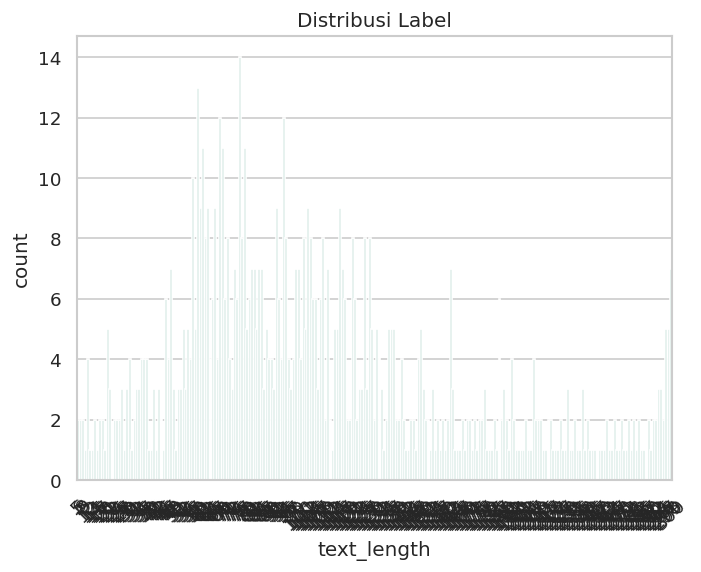

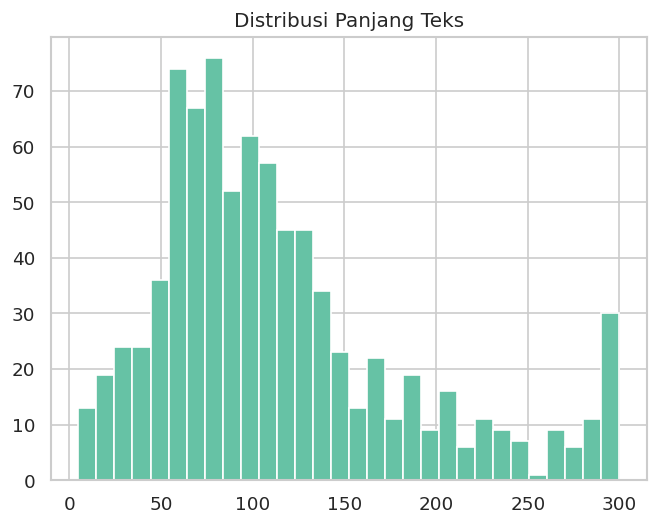


Statistik Panjang Teks:
count    831.000000
mean     114.459687
std       68.879644
min        5.000000
25%       66.000000
50%       98.000000
75%      141.000000
max      300.000000
Name: text_length, dtype: float64

Insight:
Sebagian besar ulasan memiliki panjang teks yang bervariasi dan tidak ekstrem.
Hal ini menunjukkan data cukup stabil untuk analisis sentimen.



In [10]:
# Info dataset
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Cek kolom
print("\nKolom dataset:")
print(df.columns)

# Deteksi otomatis kolom
text_col = df.columns[0]
label_col = df.columns[-1]

print("\nDetected Columns:")
print("Text :", text_col)
print("Label:", label_col)

# Distribusi label
plt.figure()
sns.countplot(x=label_col, data=df)
plt.title("Distribusi Label")
plt.xticks(rotation=45)
plt.show()

# Panjang teks
df['text_length'] = df[text_col].astype(str).apply(len)

plt.figure()
df['text_length'].hist(bins=30)
plt.title("Distribusi Panjang Teks")
plt.show()

print("\nStatistik Panjang Teks:")
print(df['text_length'].describe())

print("""
Insight:
Sebagian besar ulasan memiliki panjang teks yang bervariasi dan tidak ekstrem.
Hal ini menunjukkan data cukup stabil untuk analisis sentimen.
""")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# Copy data
df_clean = df.copy()

# Hapus missing & duplikat
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

# Cleaning teks
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

df_clean[text_col] = df_clean[text_col].apply(clean_text)

# Label encoding
le = LabelEncoder()
df_clean[label_col] = le.fit_transform(df_clean[label_col])

# Simpan hasil
df_clean.to_csv('reviews_cleaned.csv', index=False)

print("Preprocessing selesai ✅")
print(df_clean.head())

print(df_clean.isnull().sum())
print(df_clean.duplicated().sum())

Preprocessing selesai ✅
                                             reviews  label  text_length
0  kemeja nya bagusss bgttttaaaa mauuu nngisssssk...    1.0          218
1  jahitannya sih rapicuman ada benang yang ikut ...    0.0           66
2  sesuai harga agak tipis tapi masih oke kok war...    0.0          103
3  wah gila sihhh sebagus itu se worth it se  lem...    1.0          201
4  kain nya bagus halus  \ntapi kok di bukak koto...    0.0           56
reviews        0
label          0
text_length    0
dtype: int64
0
